In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score

In [3]:
train    = pd.read_csv('churn_train.csv')
test     = pd.read_csv('churn_test.csv')
accounts = pd.read_csv('accounts.csv')
demo     = pd.read_csv('demographics.csv')
services = pd.read_csv('services.csv')

print(train.shape)
print(test.shape)
print(accounts.shape)
print(demo.shape)
print(services.shape)

(4238, 2)
(1060, 1)
(5298, 8)
(5298, 8)
(47682, 3)


In [4]:
print('Churn distribution:')
print(train['Churn'].value_counts())
print()

# Descriptive stats
print('Accounts summary:')
print(accounts.describe())
print()
print('Demographics summary:')
print(demo.describe(include='all'))
print()

# Null counts
print('Nulls in accounts:')
print(accounts.isnull().sum())
print()
print('Nulls in demographics:')
print(demo.isnull().sum())

Churn distribution:
Churn
0    3189
1    1049
Name: count, dtype: int64

Accounts summary:
        CustomerNo  BaseCharges  TotalCharges
count  5298.000000  5298.000000   5288.000000
mean   3849.500000   325.467205  11928.354056
std    1529.545194   151.352954  11486.453199
min    1201.000000    91.250000     94.250000
25%    2525.250000   178.250000   2314.937500
50%    3849.500000   352.500000   7377.500000
75%    5173.750000   451.250000  19992.812500
max    6498.000000   593.750000  43424.000000

Demographics summary:
         CustomerNo Country        State      Retired   HasPartner  \
count   5298.000000    5298         5298  5298.000000  5298.000000   
unique          NaN       2            2          NaN          NaN   
top             NaN   India  Maharashtra          NaN          NaN   
freq            NaN    5293         5290          NaN          NaN   
mean    3849.500000     NaN          NaN     0.158362     1.502454   
std     1529.545194     NaN          NaN     0.36511

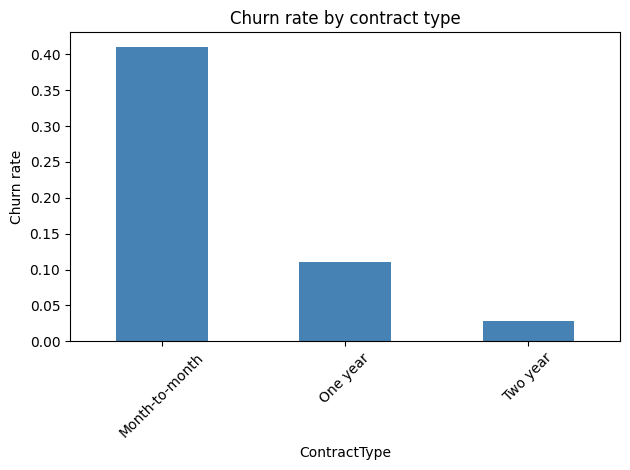

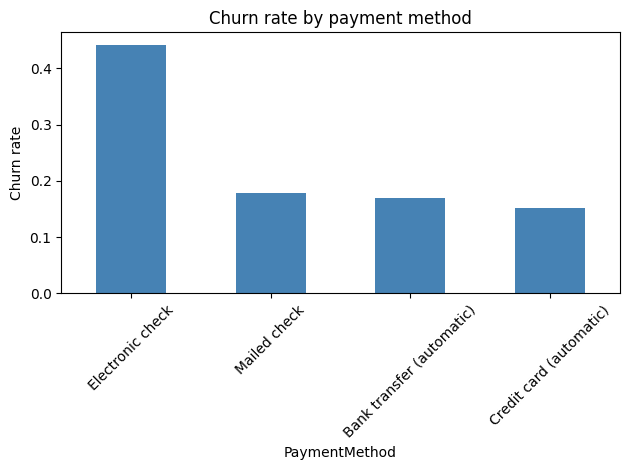

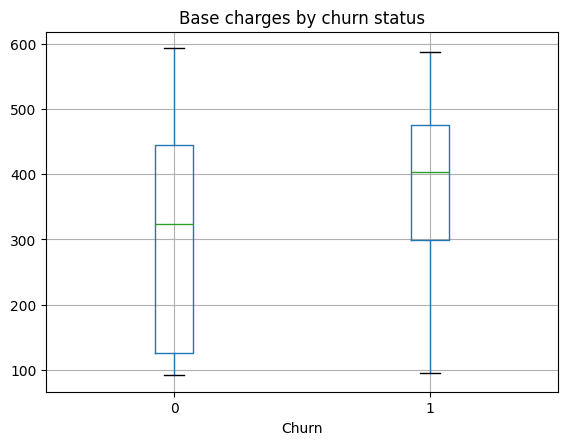

In [5]:
# Churn rate by contract type
merged_eda = train.merge(accounts, on='CustomerNo')
churn_by_contract = merged_eda.groupby('ContractType')['Churn'].mean().sort_values(ascending=False)
churn_by_contract.plot(kind='bar', title='Churn rate by contract type', color='steelblue')
plt.ylabel('Churn rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Churn rate by payment method
churn_by_payment = merged_eda.groupby('PaymentMethod')['Churn'].mean().sort_values(ascending=False)
churn_by_payment.plot(kind='bar', title='Churn rate by payment method', color='steelblue')
plt.ylabel('Churn rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Base charges distribution by churn
merged_eda.boxplot(column='BaseCharges', by='Churn')
plt.title('Base charges by churn status')
plt.suptitle('')
plt.show()

In [6]:
# Pivot services from long to wide
services_wide = services.pivot_table(
    index='CustomerNo',
    columns='TypeOfService',
    values='SeviceDetails',
    aggfunc='first'
).reset_index()

# Merge all tables together
full = accounts.merge(demo, on='CustomerNo').merge(services_wide, on='CustomerNo')

print('Full dataset shape:', full.shape)
print(full.head())

Full dataset shape: (5298, 24)
   CustomerNo  BaseCharges       DOC  TotalCharges        DOE  \
0        1201       478.50  5-1-2012       5920.00  10-Jan-11   
1        1202       103.25  5-1-2012        103.25   6-Dec-11   
2        1203       399.75  5-1-2012       5217.00  10-Jan-11   
3        1204       324.75  5-1-2012      22757.50   6-Apr-06   
4        1205       372.50  5-1-2012        372.50   6-Dec-11   

  ElectronicBilling    ContractType              PaymentMethod Country  \
0                No        One year           Electronic check   India   
1                No  Month-to-month           Electronic check   India   
2               Yes  Month-to-month  Bank transfer (automatic)   India   
3                No        One year  Bank transfer (automatic)   India   
4               Yes  Month-to-month           Electronic check   India   

         State  ...  Gender     DeviceProtection  HasPhoneService  \
0  Maharashtra  ...    Male                  Yes                

In [7]:
# Drop date columns and low-value columns
full = full.drop(columns=['DOC', 'DOE', 'Country', 'State'])

# Fill nulls with mode for categorical, median for numeric
for col in full.select_dtypes(include='object').columns:
    full[col] = full[col].fillna(full[col].mode()[0])
for col in full.select_dtypes(include='number').columns:
    full[col] = full[col].fillna(full[col].median())

# Label encode all categorical columns
le = LabelEncoder()
for col in full.select_dtypes(include='object').columns:
    full[col] = le.fit_transform(full[col].astype(str))

print('Preprocessed shape:', full.shape)
print(full.dtypes)

Preprocessed shape: (5298, 20)
CustomerNo                   int64
BaseCharges                float64
TotalCharges               float64
ElectronicBilling            int64
ContractType                 int64
PaymentMethod                int64
Retired                      int64
HasPartner                   int64
HasDependents                int64
Education                    int64
Gender                       int64
DeviceProtection             int64
HasPhoneService              int64
InternetServiceCategory      int64
MultipleLines                int64
OnlineBackup                 int64
OnlineSecurity               int64
StreamingMovies              int64
StreamingTelevision          int64
TechnicalSupport             int64
dtype: object


In [8]:
feature_cols = [c for c in full.columns if c != 'CustomerNo']

train_full = train.merge(full, on='CustomerNo')
test_full  = test.merge(full, on='CustomerNo')

X_train = train_full[feature_cols]
y_train = train_full['Churn']

X_test = test_full[feature_cols]

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('Churn balance:\n', y_train.value_counts())

X_train: (4238, 19)
X_test:  (1060, 19)
Churn balance:
 Churn
0    3189
1    1049
Name: count, dtype: int64


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

lr_train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

print(f'Train accuracy: {lr_train_acc:.3f}')
print(f'Cross-val accuracy: {lr_cv:.3f}')
print()
print(classification_report(y_train, lr.predict(X_train_scaled)))

Train accuracy: 0.744
Cross-val accuracy: 0.738

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      3189
           1       0.49      0.79      0.60      1049

    accuracy                           0.74      4238
   macro avg       0.70      0.76      0.71      4238
weighted avg       0.81      0.74      0.76      4238



In [10]:
rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy').mean()

print(f'Train accuracy: {rf_train_acc:.3f}')
print(f'Cross-val accuracy: {rf_cv:.3f}')
print()
print(classification_report(y_train, rf.predict(X_train)))

Train accuracy: 0.804
Cross-val accuracy: 0.771

              precision    recall  f1-score   support

           0       0.94      0.79      0.86      3189
           1       0.57      0.86      0.68      1049

    accuracy                           0.80      4238
   macro avg       0.76      0.82      0.77      4238
weighted avg       0.85      0.80      0.81      4238



In [16]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)

gb_train_acc = accuracy_score(y_train, gb.predict(X_train))
gb_cv = cross_val_score(gb, X_train, y_train, cv=5, scoring='accuracy').mean()

print(f'Train accuracy: {gb_train_acc:.3f}')
print(f'Cross-val accuracy: {gb_cv:.3f}')
print()
print(classification_report(y_train, gb.predict(X_train)))

Train accuracy: 0.845
Cross-val accuracy: 0.819

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      3189
           1       0.74      0.58      0.65      1049

    accuracy                           0.84      4238
   macro avg       0.80      0.76      0.77      4238
weighted avg       0.84      0.84      0.84      4238



              Model  Train Accuracy  CV Accuracy
Logistic Regression        0.744219     0.737856
      Random Forest        0.803917     0.771125
  Gradient Boosting        0.869278     0.810761


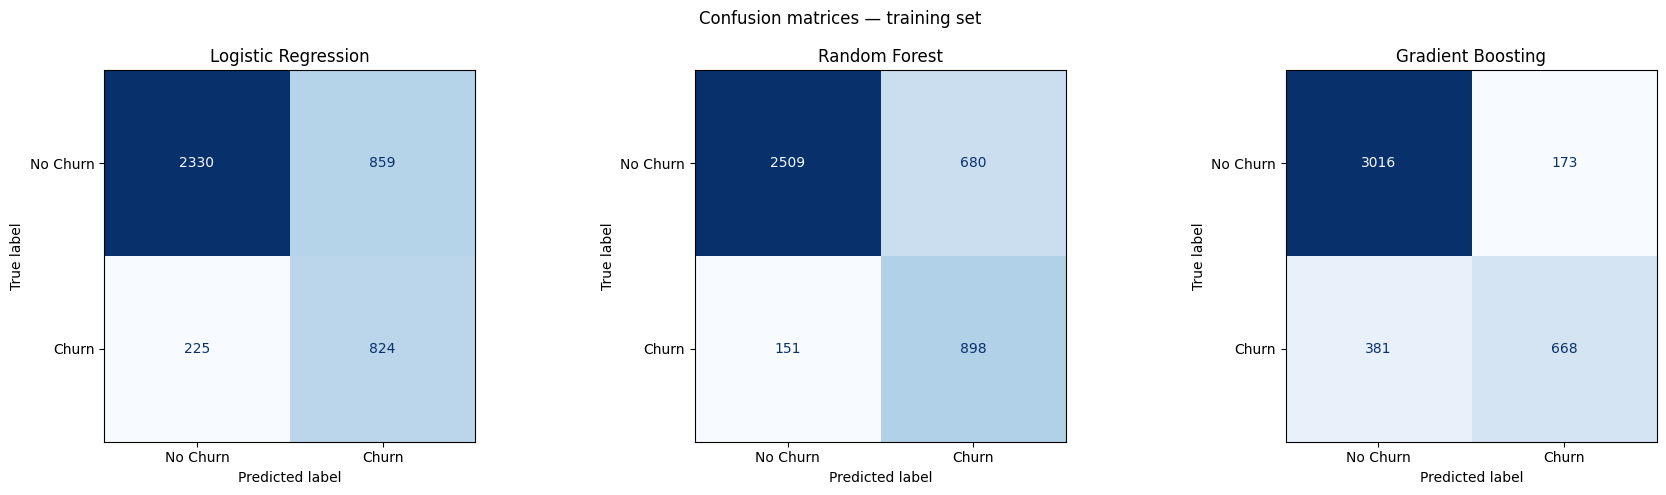

In [12]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Train Accuracy': [lr_train_acc, rf_train_acc, gb_train_acc],
    'CV Accuracy': [lr_cv, rf_cv, gb_cv]
})
print(results.to_string(index=False))

# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model, X) in zip(axes, [
    ('Logistic Regression', lr, X_train_scaled),
    ('Random Forest', rf, X_train),
    ('Gradient Boosting', gb, X_train)
]):
    cm = confusion_matrix(y_train, model.predict(X))
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.suptitle('Confusion matrices — training set')
plt.tight_layout()
plt.show()

In [17]:
test_preds = gb.predict(X_test)

submission = pd.DataFrame({
    'CustomerNo': test['CustomerNo'],
    'Churn': test_preds
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print('Saved submission.csv')

   CustomerNo  Churn
0        1203      0
1        1204      0
2        1208      0
3        1220      0
4        1221      0
5        1225      0
6        1229      0
7        1246      1
8        1249      1
9        1251      0
Saved submission.csv
